Libraries loaded successfully
Feature cols   : 21
Test set       : (384, 21)
Crisis cases   : 60
Policy scenarios defined:
  Policy A-20 (Debt -20%): {'debt_financial': -0.2}
  Policy A-40 (Debt -40%): {'debt_financial': -0.4}
  Policy A-60 (Debt -60%): {'debt_financial': -0.6}
  Policy B-20 (Income +20%): {'h19_pers_income2': 0.2}
  Policy B-40 (Income +40%): {'h19_pers_income2': 0.4}
  Policy B-60 (Income +60%): {'h19_pers_income2': 0.6}
  Policy C (A-40+B-40): {'debt_financial': -0.4, 'h19_pers_income2': 0.4}
Baseline crisis rate (test, crisis cases) : 51.7%
Baseline mean prob                        : 0.5367
Policy A-20 (Debt -20%)      | crisis rate: 51.7% | prob drop: 0.0195 | rescued: 0
Policy A-40 (Debt -40%)      | crisis rate: 46.7% | prob drop: 0.0429 | rescued: 3
Policy A-60 (Debt -60%)      | crisis rate: 45.0% | prob drop: 0.0655 | rescued: 4
Policy B-20 (Income +20%)    | crisis rate: 60.0% | prob drop: -0.0403 | rescued: -5
Policy B-40 (Income +40%)    | crisis rate: 58.

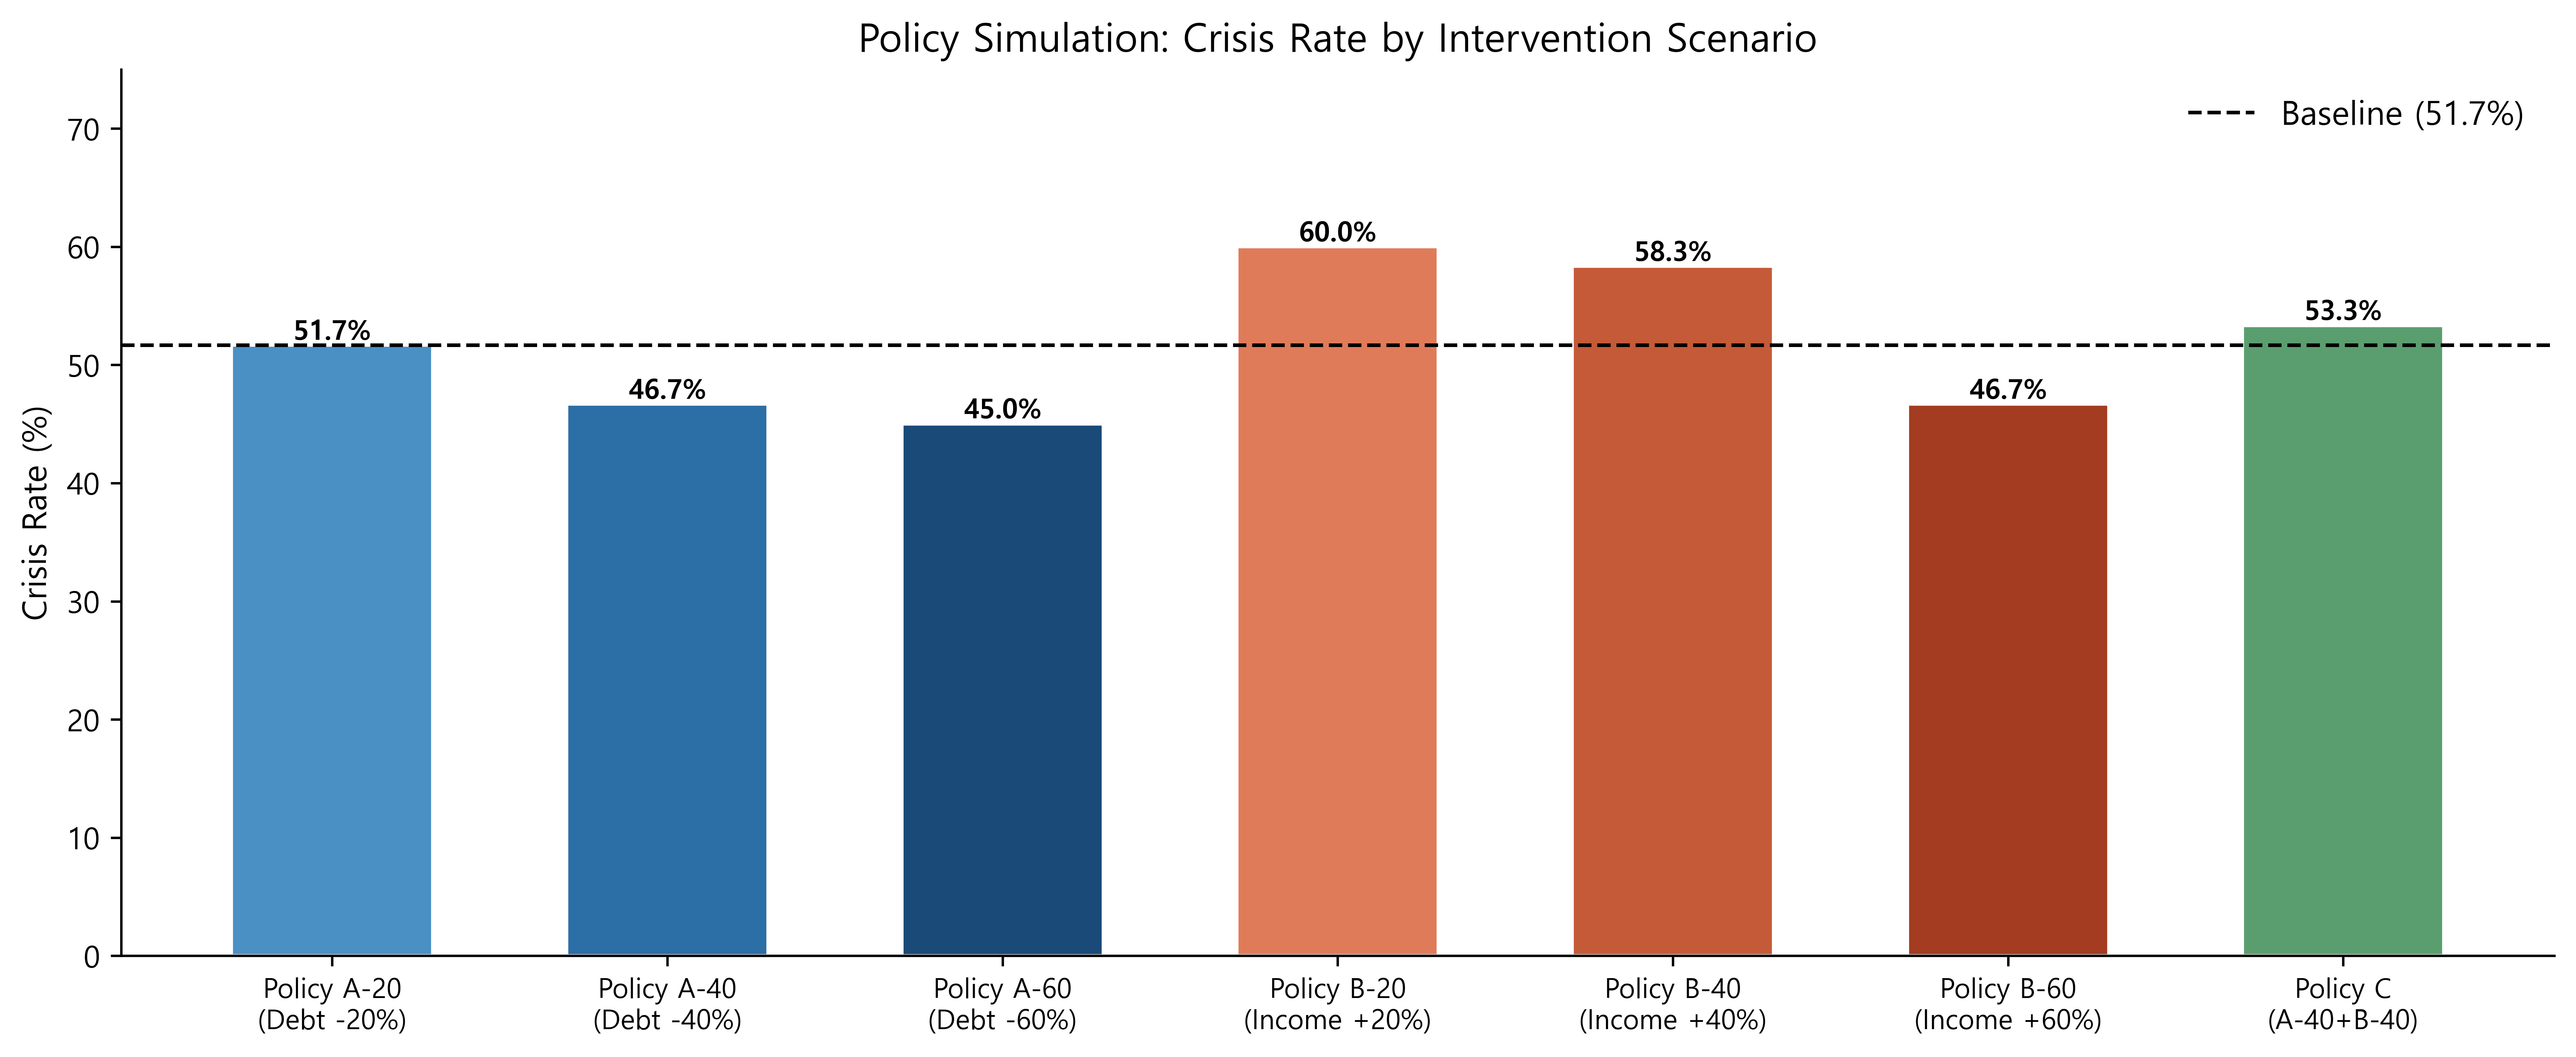

Saved -> outputs/24_policy_crisis_rate.png


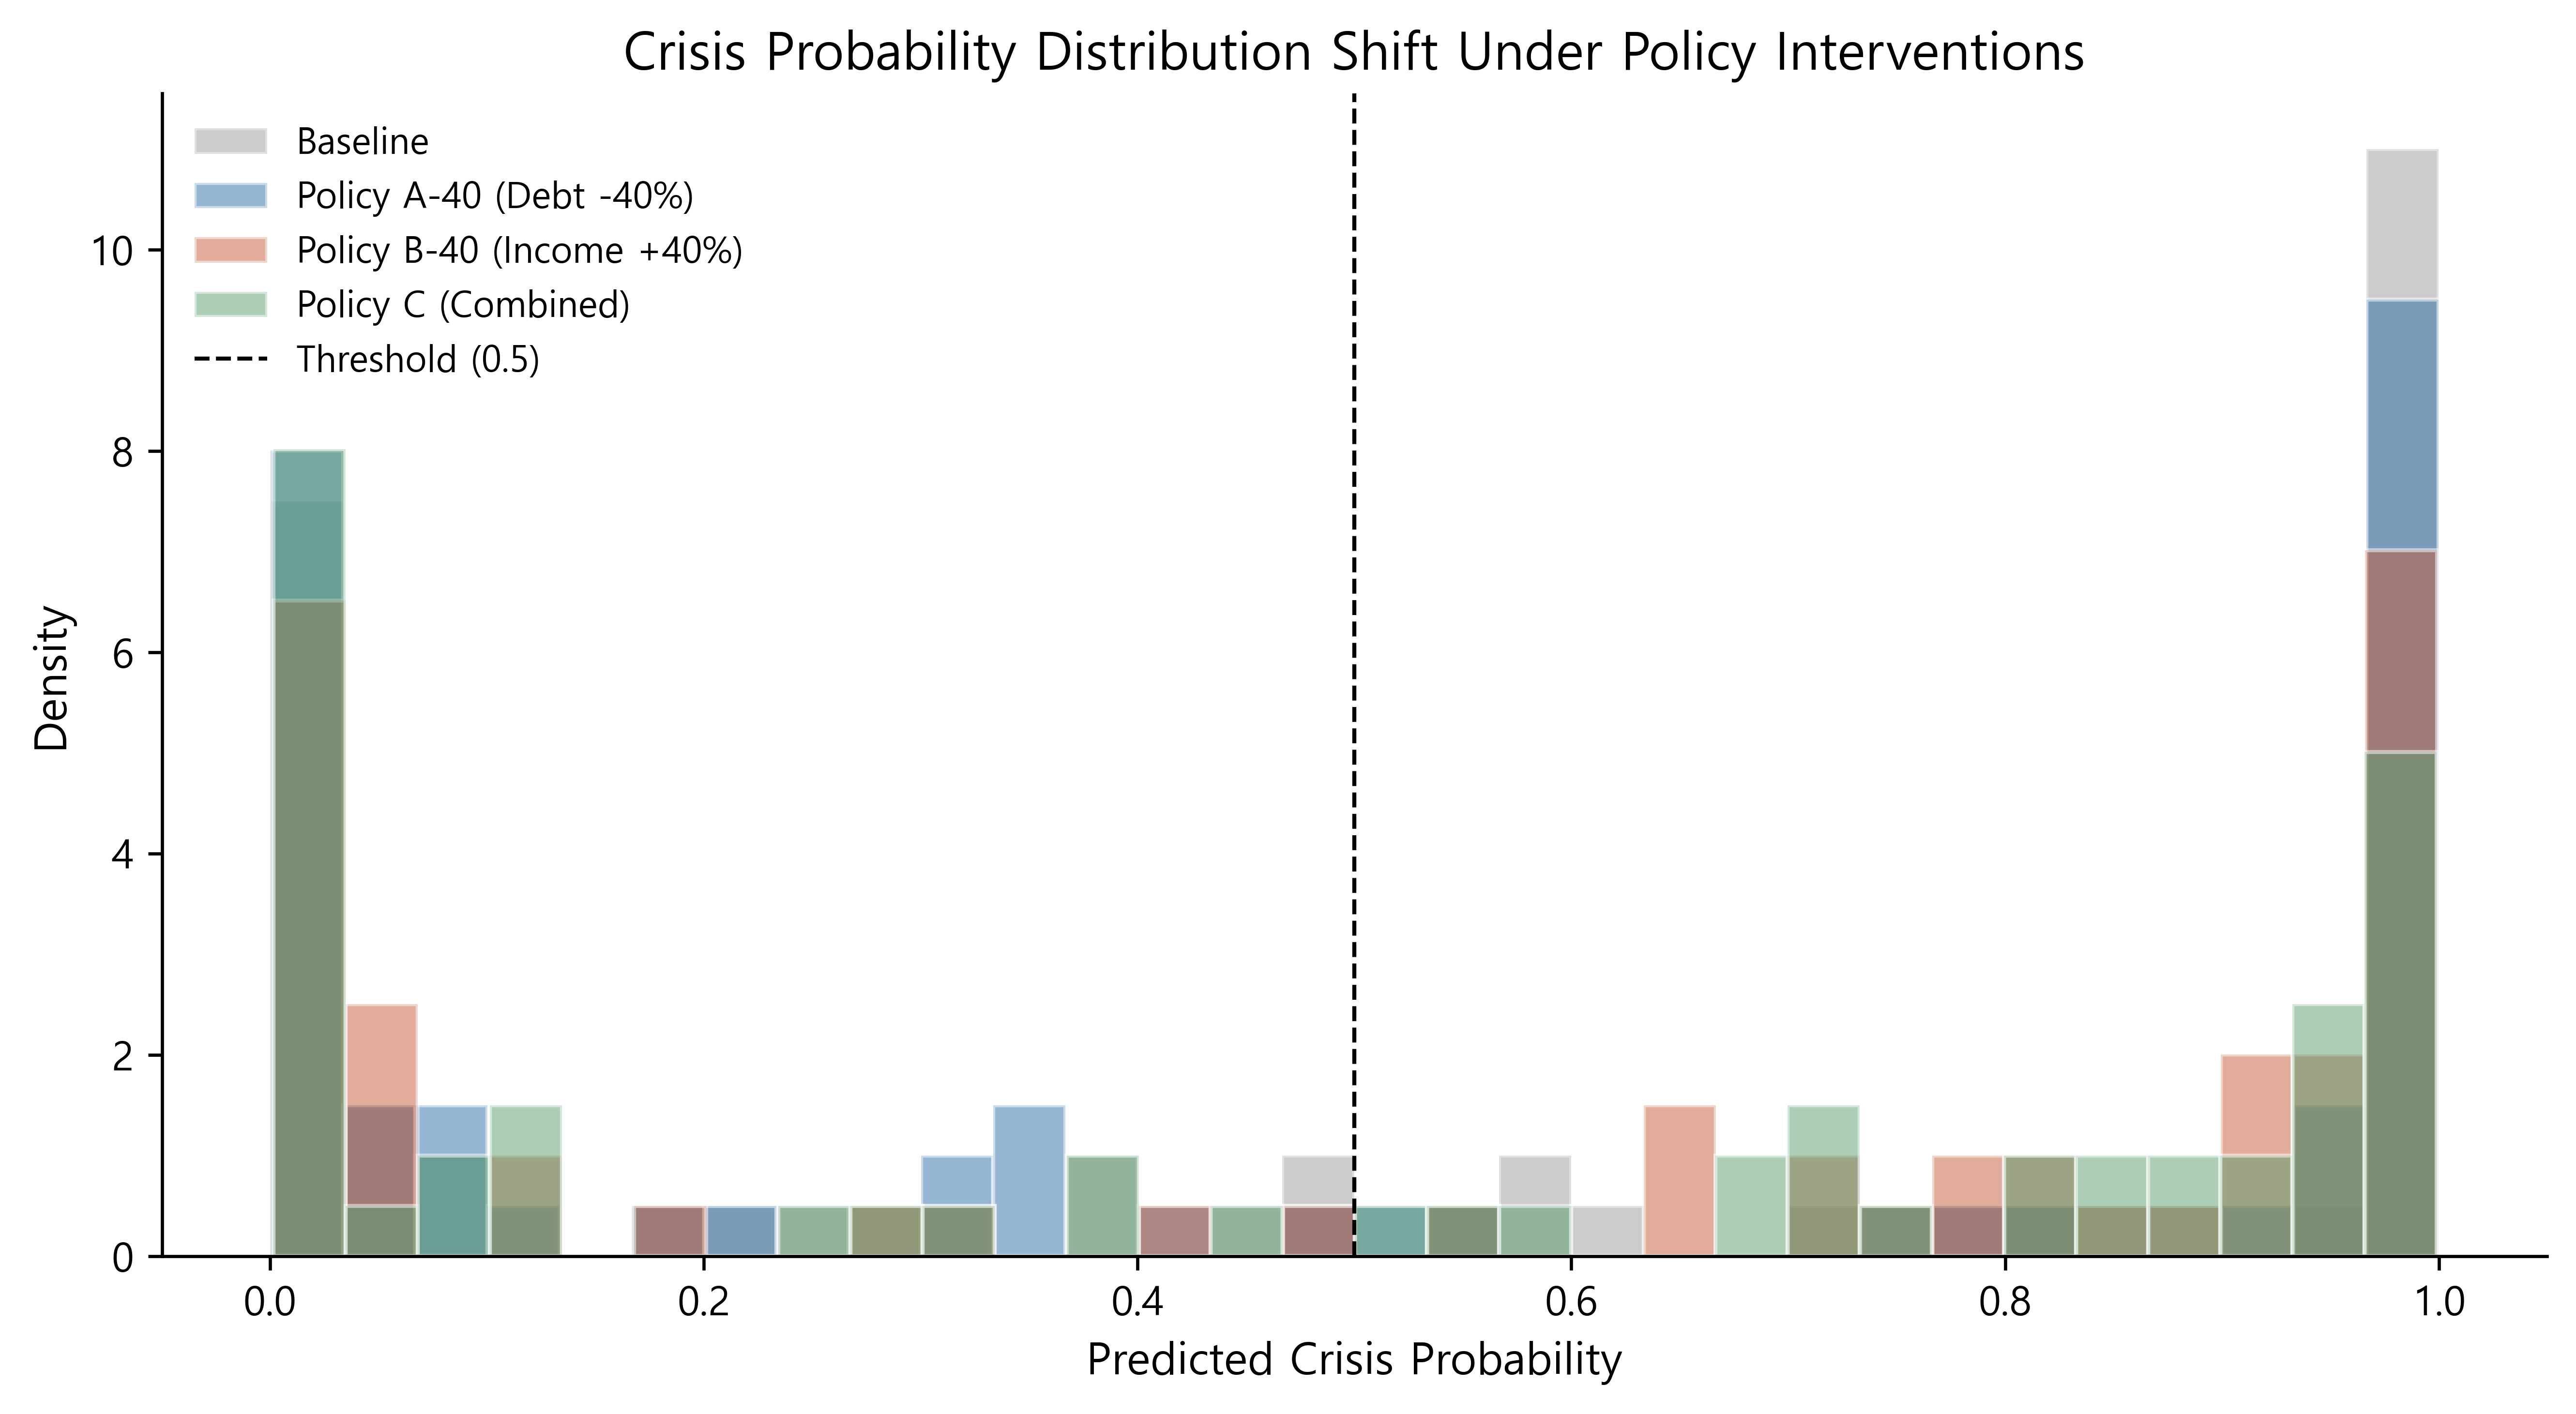

Saved -> outputs/25_policy_prob_shift.png
=== Policy C effect by employment status ===
  Subgroup  N  Baseline prob  Post-policy prob  Prob reduction
  Employed 23         0.2343            0.3335         -0.0992
Unemployed 11         0.5292            0.4127          0.1165
  Inactive  3         0.6604            0.6413          0.0191


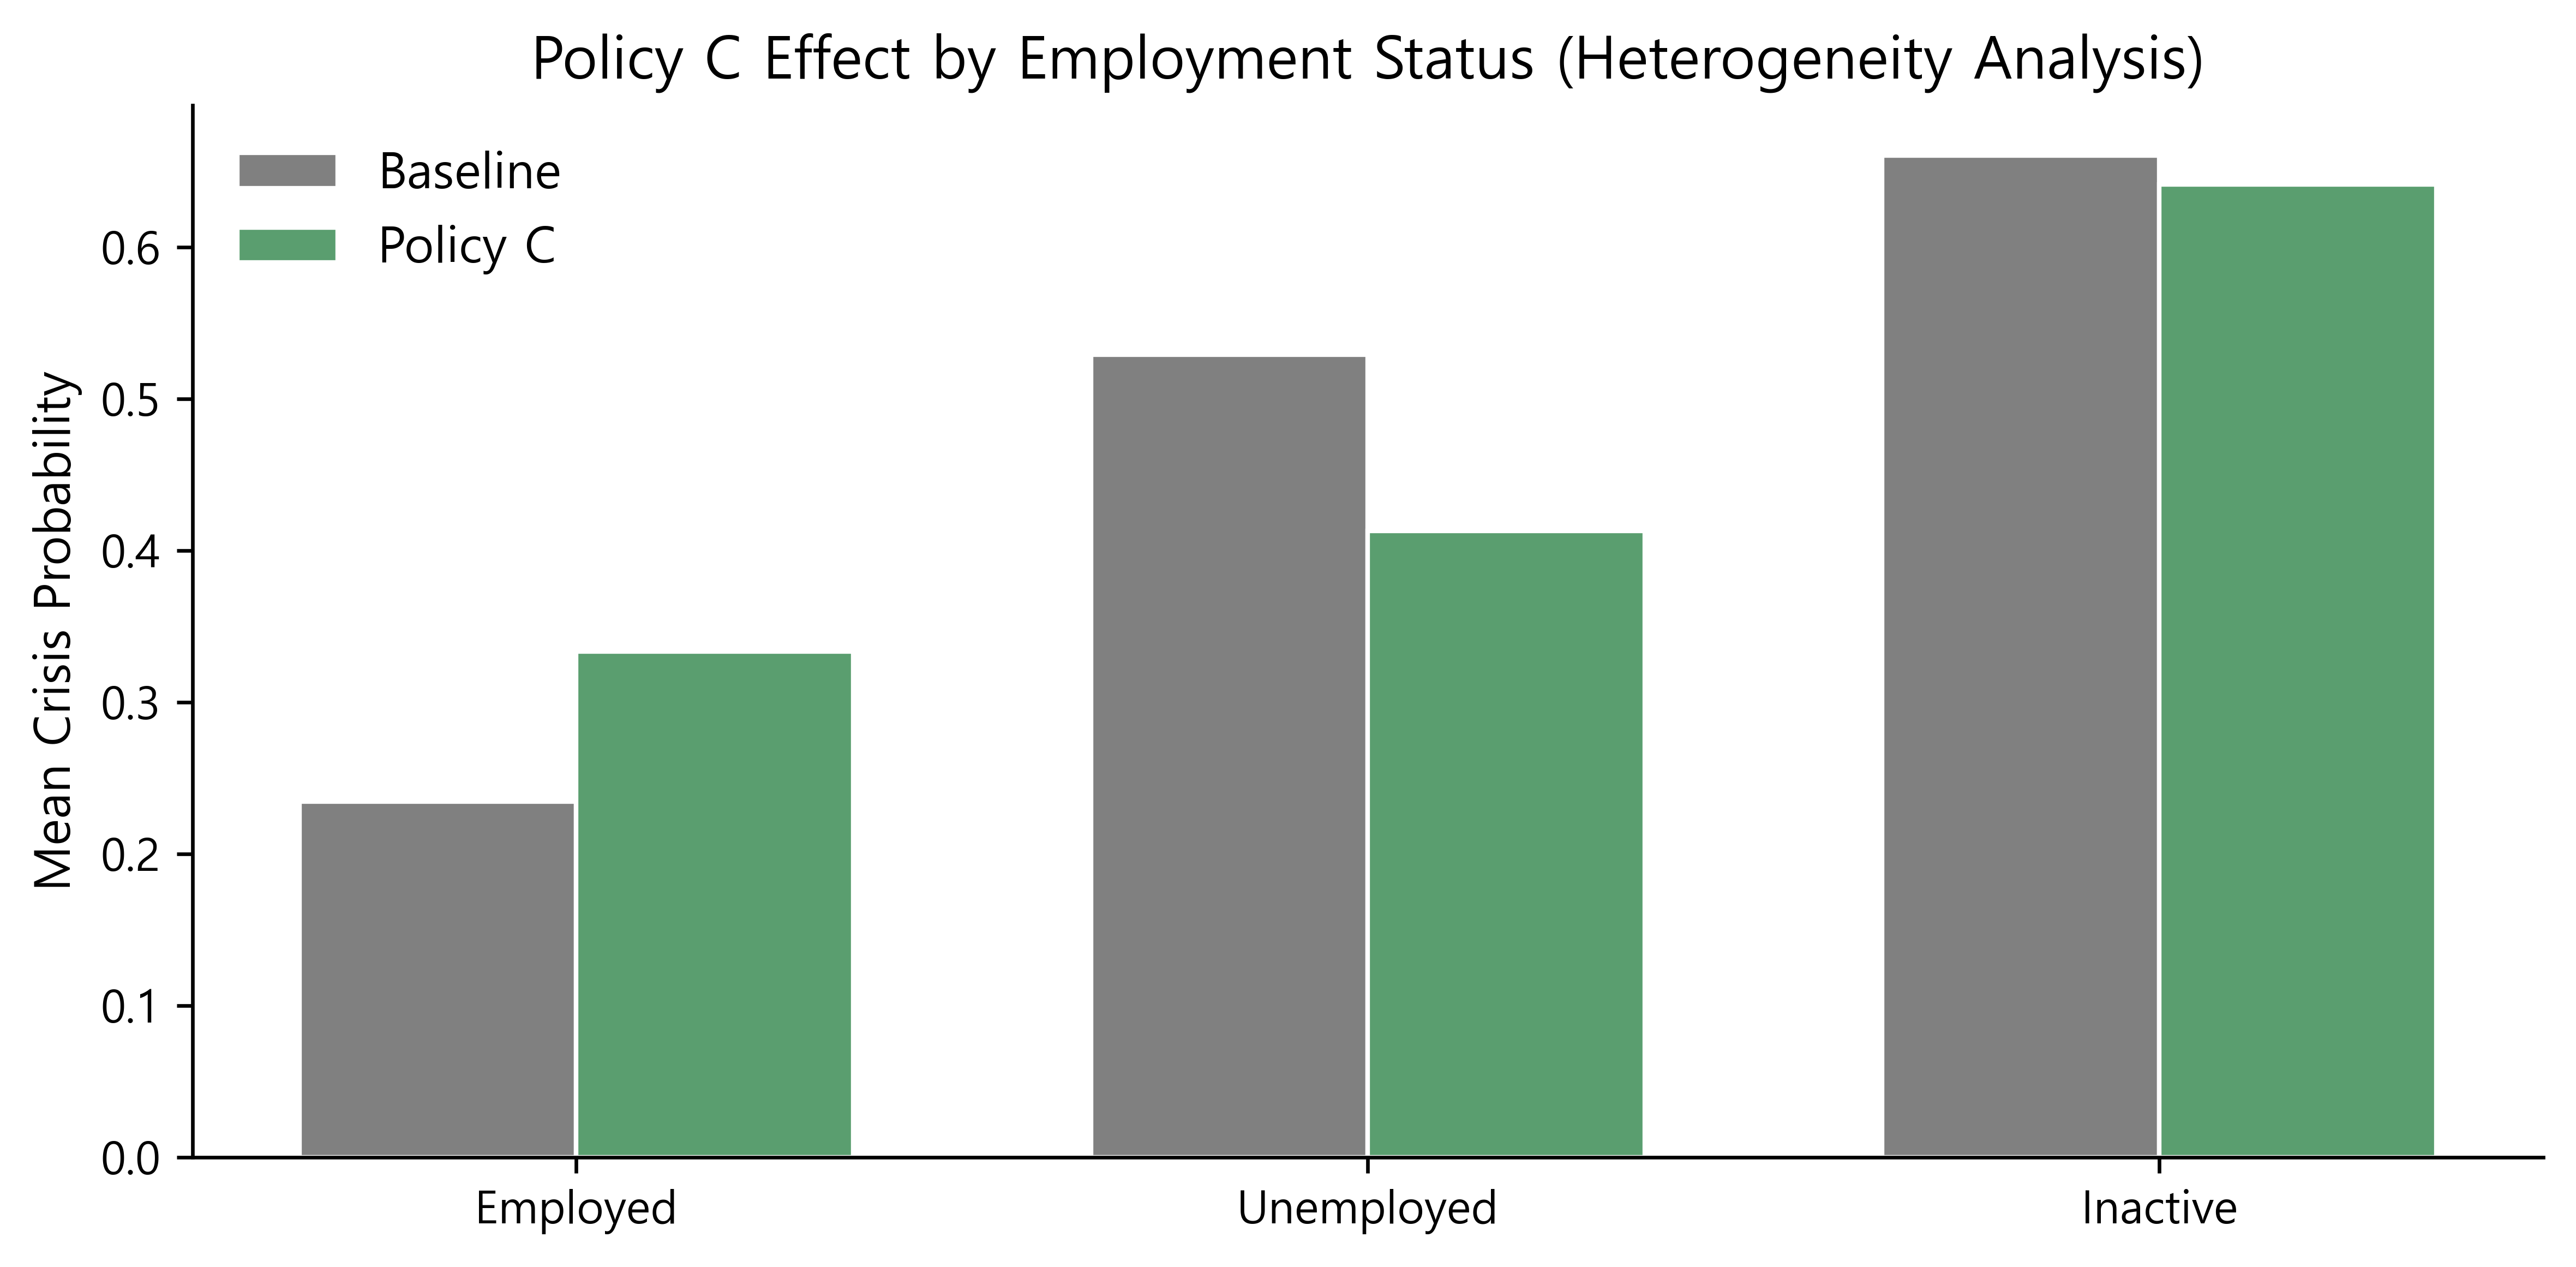

Saved -> outputs/26_policy_heterogeneity.png


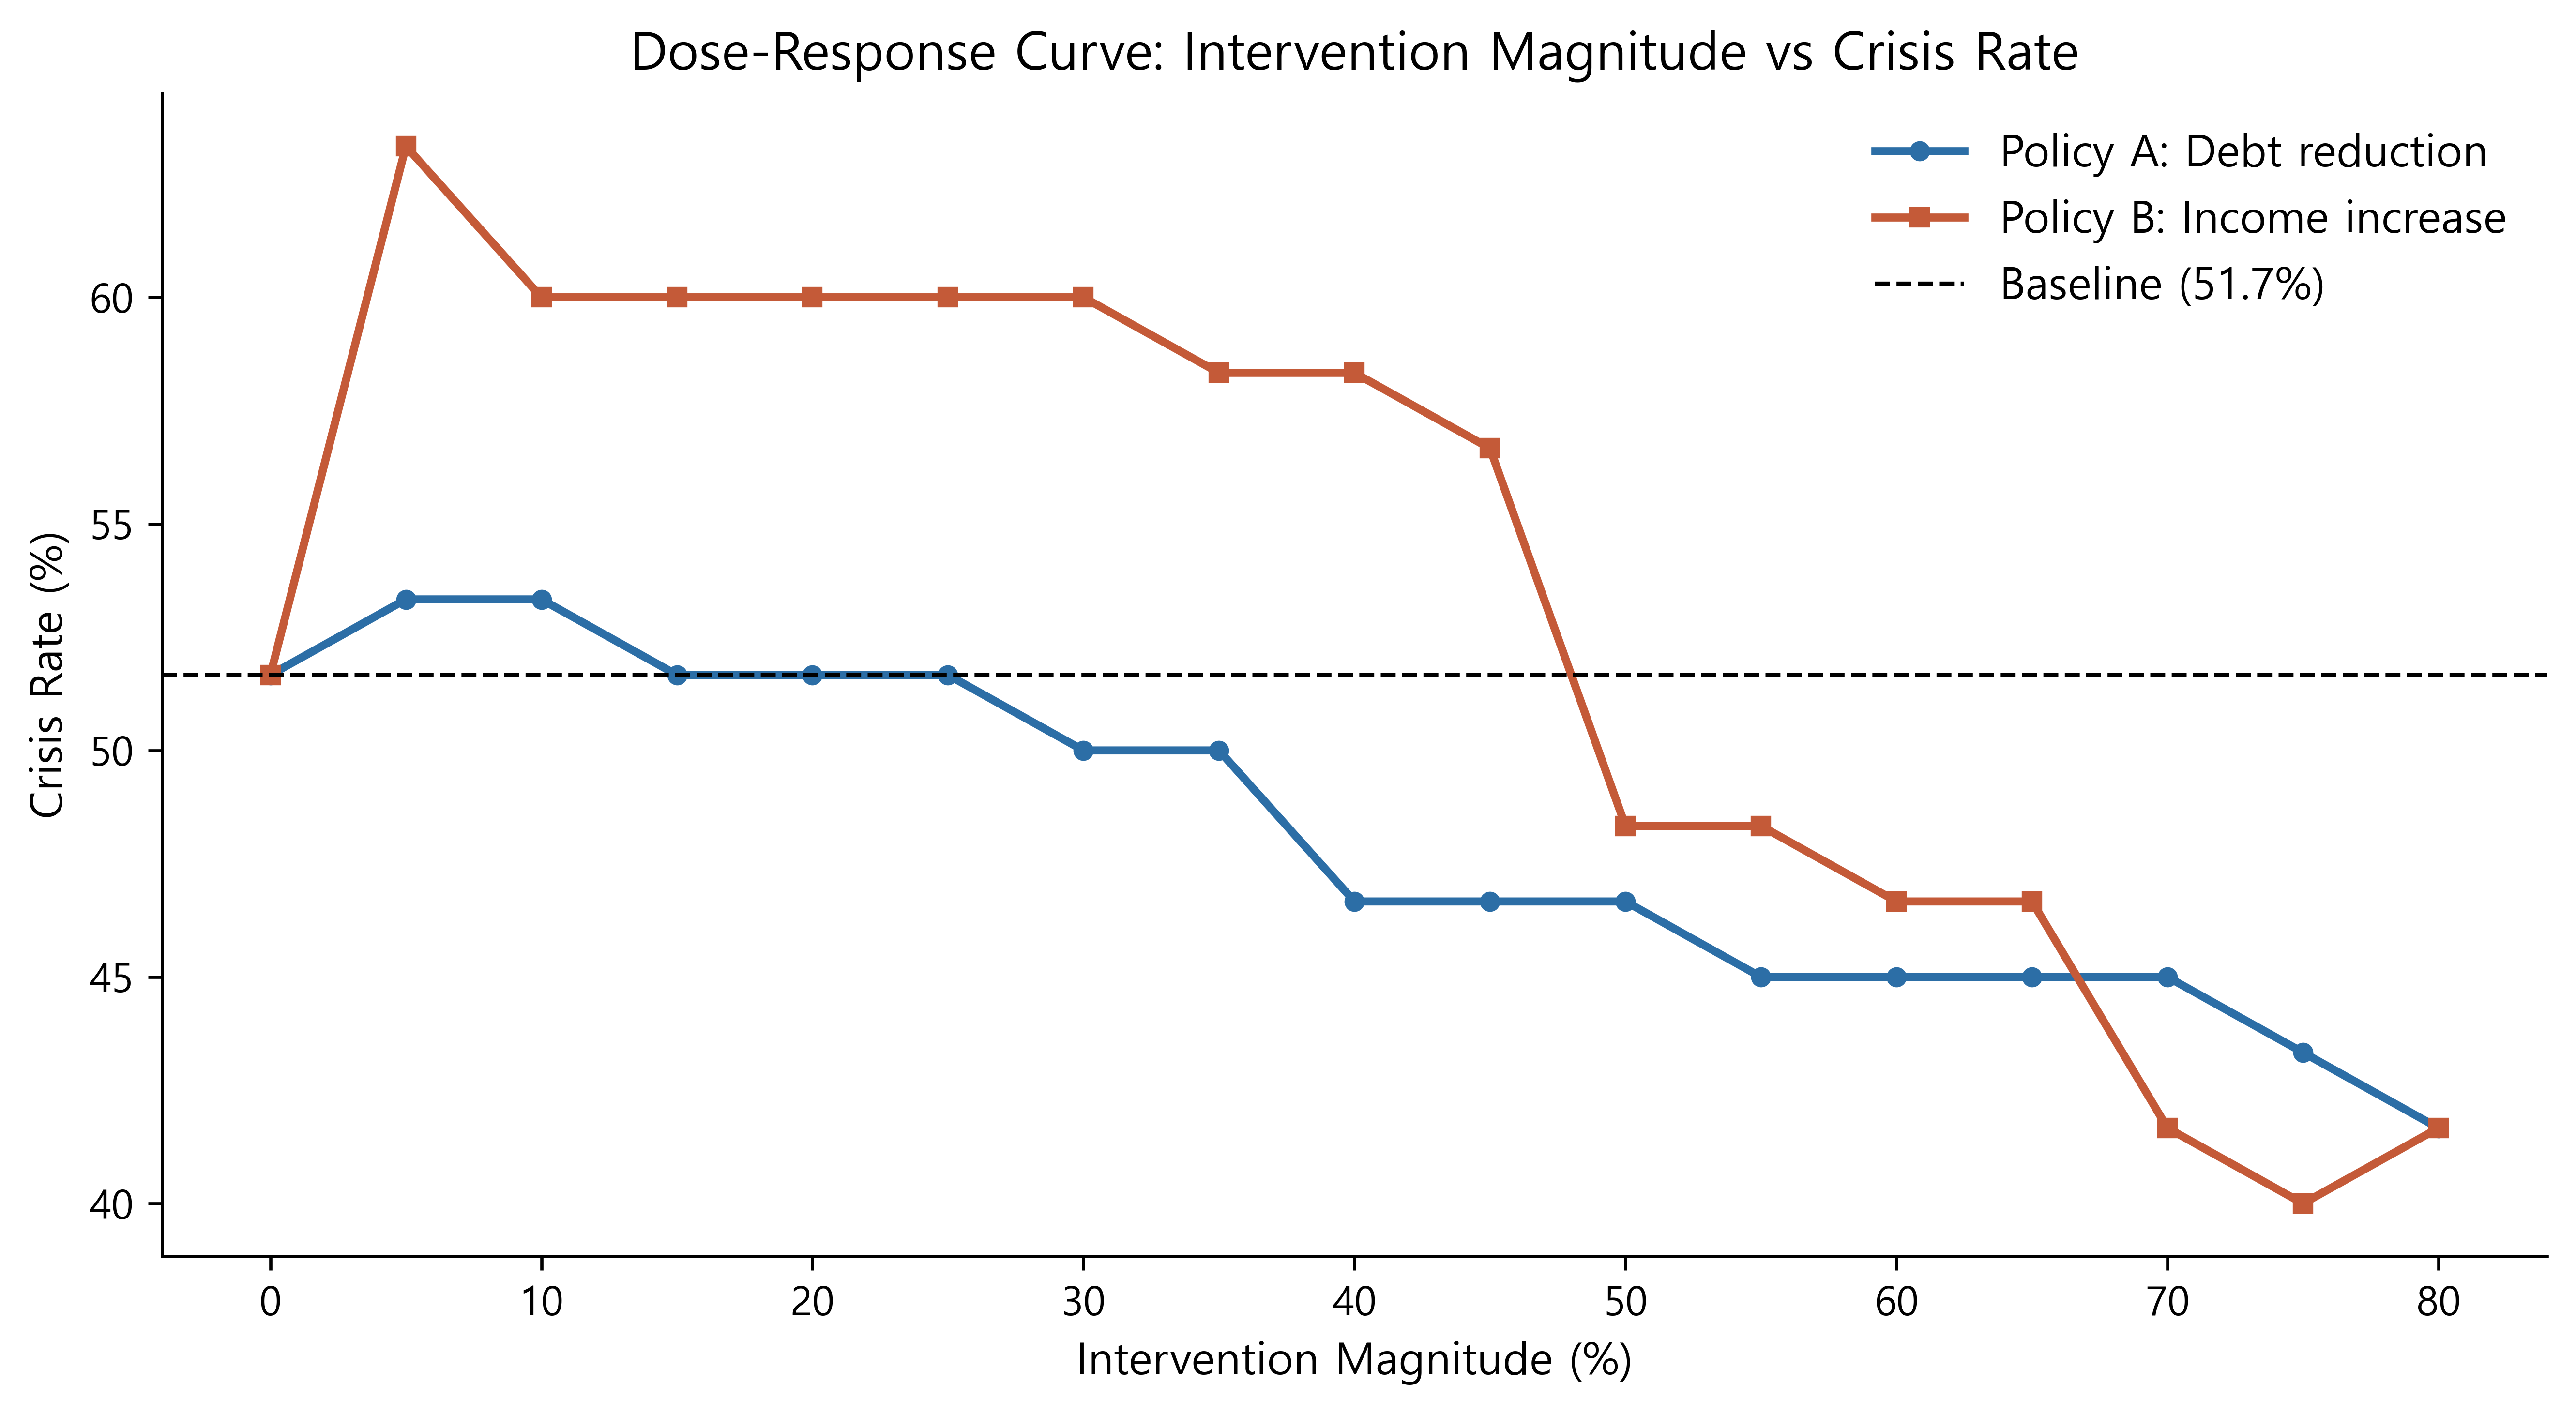

Saved -> outputs/27_dose_response.png
Saved -> outputs/dose_response.csv

All policy simulation outputs saved to outputs/


In [1]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm.pkl')
df      = pd.read_csv('../data/youth_debt_preprocessed.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
imputer = joblib.load('../outputs/imputer.pkl')

FEATURE_COLS = pd.read_csv('../data/feature_cols.csv').iloc[:, 0].tolist()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

# Crisis cases only
crisis_mask = y_test_r == 1
X_crisis    = X_test_r[crisis_mask].copy().reset_index(drop=True)

print(f"Feature cols   : {len(FEATURE_COLS)}")
print(f"Test set       : {X_test_r.shape}")
print(f"Crisis cases   : {X_crisis.shape[0]}")


# ─────────────────────────────────────────────
# Cell 3 | Define policy scenarios
# ─────────────────────────────────────────────
# Based on NiCE/DiCE findings: debt_financial and h19_pers_income2
# are the two most actionable intervention variables

# Policy A: Financial loan reduction (debt relief)
#   - Simulate 20%, 40%, 60% reduction in debt_financial
# Policy B: Income stabilization (temporary worker income support)
#   - Simulate 20%, 40%, 60% increase in h19_pers_income2
# Policy C: Combined intervention (A40% + B40%)

POLICIES = {
    'Policy A-20\n(Debt -20%)' : {'debt_financial': -0.20},
    'Policy A-40\n(Debt -40%)' : {'debt_financial': -0.40},
    'Policy A-60\n(Debt -60%)' : {'debt_financial': -0.60},
    'Policy B-20\n(Income +20%)': {'h19_pers_income2': +0.20},
    'Policy B-40\n(Income +40%)': {'h19_pers_income2': +0.40},
    'Policy B-60\n(Income +60%)': {'h19_pers_income2': +0.60},
    'Policy C\n(A-40+B-40)'    : {'debt_financial': -0.40,
                                   'h19_pers_income2': +0.40},
}

print("Policy scenarios defined:")
for k, v in POLICIES.items():
    print(f"  {k.replace(chr(10),' ')}: {v}")


# ─────────────────────────────────────────────
# Cell 4 | Simulate policy effects
# ─────────────────────────────────────────────
baseline_probs = lgbm.predict_proba(X_crisis.values)[:, 1]
baseline_crisis_rate = (baseline_probs >= 0.5).mean()

print(f"Baseline crisis rate (test, crisis cases) : {baseline_crisis_rate:.1%}")
print(f"Baseline mean prob                        : {baseline_probs.mean():.4f}")

sim_results = {}

for policy_name, changes in POLICIES.items():
    X_sim = X_crisis.copy()

    for feat, delta in changes.items():
        if feat in X_sim.columns:
            if delta < 0:
                # Reduction: multiply by (1 + delta)
                X_sim[feat] = X_sim[feat] * (1 + delta)
                X_sim[feat] = X_sim[feat].clip(lower=0)
            else:
                # Increase: add delta proportion of column mean
                col_mean = X_crisis[feat].mean()
                X_sim[feat] = X_sim[feat] + col_mean * delta

    sim_probs       = lgbm.predict_proba(X_sim.values)[:, 1]
    sim_crisis_rate = (sim_probs >= 0.5).mean()
    prob_reduction  = baseline_probs.mean() - sim_probs.mean()
    rate_reduction  = baseline_crisis_rate - sim_crisis_rate
    n_rescued       = int((baseline_probs >= 0.5).sum() -
                          (sim_probs >= 0.5).sum())

    sim_results[policy_name] = {
        'mean_prob'     : sim_probs.mean(),
        'crisis_rate'   : sim_crisis_rate,
        'prob_reduction': prob_reduction,
        'rate_reduction': rate_reduction,
        'n_rescued'     : n_rescued,
        'probs'         : sim_probs,
    }

    label = policy_name.replace('\n', ' ')
    print(f"{label:<28} | crisis rate: {sim_crisis_rate:.1%} "
          f"| prob drop: {prob_reduction:.4f} "
          f"| rescued: {n_rescued}")


# ─────────────────────────────────────────────
# Cell 5 | Policy effect summary table
# ─────────────────────────────────────────────
rows = []
for name, res in sim_results.items():
    rows.append({
        'Policy'           : name.replace('\n', ' '),
        'Crisis Rate'      : f"{res['crisis_rate']:.1%}",
        'Rate Reduction'   : f"{res['rate_reduction']:.1%}",
        'Mean Prob Drop'   : f"{res['prob_reduction']:.4f}",
        'Cases Rescued'    : res['n_rescued'],
    })

summary_tbl = pd.DataFrame(rows)
print("\n=== Policy Simulation Summary ===")
print(summary_tbl.to_string(index=False))

summary_tbl.to_csv('../outputs/policy_simulation_summary.csv',
                   index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/policy_simulation_summary.csv")


# ─────────────────────────────────────────────
# Cell 6 | Bar chart — crisis rate by policy
# ─────────────────────────────────────────────
policy_names  = [k.replace('\n', '\n') for k in sim_results.keys()]
crisis_rates  = [v['crisis_rate'] * 100 for v in sim_results.values()]
colors = ['#4a90c4','#2c6ea6','#1a4a78',
          '#e07b5a','#c45a38','#a33c20',
          '#5a9e6f']

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(len(policy_names)), crisis_rates,
              color=colors, edgecolor='white', width=0.6)

# Baseline line
ax.axhline(baseline_crisis_rate * 100, color='black',
           linestyle='--', lw=1.2, label=f'Baseline ({baseline_crisis_rate:.1%})')

for bar, val in zip(bars, crisis_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.5, f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(policy_names)))
ax.set_xticklabels(policy_names, fontsize=9)
ax.set_ylabel('Crisis Rate (%)')
ax.set_title('Policy Simulation: Crisis Rate by Intervention Scenario')
ax.legend(frameon=False)
ax.set_ylim(0, max(crisis_rates) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/24_policy_crisis_rate.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/24_policy_crisis_rate.png")


# ─────────────────────────────────────────────
# Cell 7 | Probability distribution shift by policy
# ─────────────────────────────────────────────
key_policies = [
    ('Policy A-40\n(Debt -40%)',  '#2c6ea6', 'Policy A-40 (Debt -40%)'),
    ('Policy B-40\n(Income +40%)', '#c45a38', 'Policy B-40 (Income +40%)'),
    ('Policy C\n(A-40+B-40)',      '#5a9e6f', 'Policy C (Combined)'),
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(baseline_probs, bins=30, alpha=0.4, color='gray',
        label='Baseline', edgecolor='white', density=True)

for key, color, label in key_policies:
    if key in sim_results:
        ax.hist(sim_results[key]['probs'], bins=30, alpha=0.5,
                color=color, label=label,
                edgecolor='white', density=True)

ax.axvline(0.5, color='black', linestyle='--', lw=1.0, label='Threshold (0.5)')
ax.set_xlabel('Predicted Crisis Probability')
ax.set_ylabel('Density')
ax.set_title('Crisis Probability Distribution Shift Under Policy Interventions')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/25_policy_prob_shift.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/25_policy_prob_shift.png")


# ─────────────────────────────────────────────
# Cell 8 | Heterogeneity analysis — by subgroup
# ─────────────────────────────────────────────
# Merge X_crisis with demographic info from full dataset
df_crisis = df[df['debt_crisis'] == 1].copy().reset_index(drop=True)

# Employment status subgroup
emp_labels = {1: 'Employed', 2: 'Unemployed', 3: 'Inactive'}
policy_key = 'Policy C\n(A-40+B-40)'

if policy_key in sim_results and 'employment_status' in X_crisis.columns:
    subgroup_rows = []

    for emp_val, emp_label in emp_labels.items():
        mask = X_crisis['employment_status'] == emp_val
        if mask.sum() == 0:
            continue

        base_p   = baseline_probs[mask]
        sim_p    = sim_results[policy_key]['probs'][mask]
        reduction = base_p.mean() - sim_p.mean()

        subgroup_rows.append({
            'Subgroup'         : emp_label,
            'N'                : int(mask.sum()),
            'Baseline prob'    : round(base_p.mean(), 4),
            'Post-policy prob' : round(sim_p.mean(), 4),
            'Prob reduction'   : round(reduction, 4),
        })

    subgroup_df = pd.DataFrame(subgroup_rows)
    print("=== Policy C effect by employment status ===")
    print(subgroup_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(subgroup_df))
    w = 0.35
    ax.bar(x - w/2, subgroup_df['Baseline prob'],
           width=w, color='gray', label='Baseline', edgecolor='white')
    ax.bar(x + w/2, subgroup_df['Post-policy prob'],
           width=w, color='#5a9e6f', label='Policy C', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(subgroup_df['Subgroup'])
    ax.set_ylabel('Mean Crisis Probability')
    ax.set_title('Policy C Effect by Employment Status (Heterogeneity Analysis)')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/26_policy_heterogeneity.png', **SAVE_KW)
    plt.show()
    print("Saved -> outputs/26_policy_heterogeneity.png")


# ─────────────────────────────────────────────
# Cell 9 | Dose-response curve
# ─────────────────────────────────────────────
# How does crisis rate change as debt reduction increases 0~80%?
debt_reductions = np.arange(0, 0.85, 0.05)
income_increases = np.arange(0, 0.85, 0.05)

rate_debt   = []
rate_income = []

for delta in debt_reductions:
    X_sim = X_crisis.copy()
    if 'debt_financial' in X_sim.columns:
        X_sim['debt_financial'] = (X_sim['debt_financial'] * (1 - delta)).clip(lower=0)
    probs = lgbm.predict_proba(X_sim.values)[:, 1]
    rate_debt.append((probs >= 0.5).mean() * 100)

for delta in income_increases:
    X_sim = X_crisis.copy()
    if 'h19_pers_income2' in X_sim.columns:
        col_mean = X_crisis['h19_pers_income2'].mean()
        X_sim['h19_pers_income2'] = X_sim['h19_pers_income2'] + col_mean * delta
    probs = lgbm.predict_proba(X_sim.values)[:, 1]
    rate_income.append((probs >= 0.5).mean() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(debt_reductions * 100, rate_debt,
        color='#2c6ea6', lw=2, marker='o', markersize=4,
        label='Policy A: Debt reduction')
ax.plot(income_increases * 100, rate_income,
        color='#c45a38', lw=2, marker='s', markersize=4,
        label='Policy B: Income increase')
ax.axhline(baseline_crisis_rate * 100, color='black',
           linestyle='--', lw=1.0, label=f'Baseline ({baseline_crisis_rate:.1%})')
ax.set_xlabel('Intervention Magnitude (%)')
ax.set_ylabel('Crisis Rate (%)')
ax.set_title('Dose-Response Curve: Intervention Magnitude vs Crisis Rate')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/27_dose_response.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/27_dose_response.png")


# ─────────────────────────────────────────────
# Cell 10 | Save all simulation results
# ─────────────────────────────────────────────
dose_df = pd.DataFrame({
    'magnitude_pct'  : debt_reductions * 100,
    'crisis_rate_debt'  : rate_debt,
    'crisis_rate_income': rate_income,
})
dose_df.to_csv('../outputs/dose_response.csv', index=False, encoding='utf-8-sig')
print("Saved -> outputs/dose_response.csv")
print("\nAll policy simulation outputs saved to outputs/")